In [1]:
import os
import subprocess
import rasterio
import rioxarray as rxr
import numpy as np
import geopandas as gpd
from geocube.vector import vectorize
from rasterio.mask import mask
import matplotlib.pyplot as plt

In [81]:
def read_and_mask_raster(raster_path, min_val, max_val, nodata_val=None):
    """
    Read a raster file and mask values outside the specified range.
    
    Parameters:
        raster_path (str): Path to the raster file.
        min_val (float): Minimum value of the range.
        max_val (float): Maximum value of the range.
        nodata_val (float): Value to assign to no data; if None, uses raster's nodata value.
    
    Returns:
        masked_array (numpy array): The masked raster data.
        profile (dict): The raster file's profile.
    """
    with rasterio.open(raster_path) as src:
        array = src.read(1) # Read first band
        profile = src.profile
        
        if nodata_val is None:
            nodata_val = profile['nodata']
        
        # Mask values outside the specified range
        array[(array < min_val) | (array > max_val)] = nodata_val
        
        return array, profile
    
def getFeatures(gdf):
        """Function to parse features from GeoDataFrame in such a manner that rasterio wants them"""
        import json
        return [json.loads(gdf.to_json())['features'][0]['geometry']]

def clip_raster_with_vector(raster_array, raster_profile, vector_path, output_path):
    """
    Clip a raster array with a vector mask and save the output.
    
    Parameters:
        raster_array (numpy array): The raster data to clip.
        raster_profile (dict): The raster file's profile.
        vector_path (str): Path to the vector mask file.
        output_path (str): Path where the clipped raster will be saved.
    """
    # Load the vector mask
    polygon = gpd.read_file(vector_path)
    
    # Update profile to match the number of layers in the masked array
    raster_profile.update({
        "height": raster_array.shape[0],
        "width": raster_array.shape[1],
        "driver": "GTiff"
    })

    polygon = polygon.to_crs(crs=raster_profile['crs'])
    
    with rasterio.open(output_path, 'w', **raster_profile) as dest:
        out_image, out_transform = mask(raster_array, getFeatures(polygon), crop=True)
        dest.write(out_image)

In [3]:
import os
from dotenv import load_dotenv
from pathlib import Path

In [4]:
load_dotenv()  # take environment variables from .env.

DATA_FOLDER = Path(os.getenv("DATA_FOLDER")) 
IMAGERY_FOLDER = DATA_FOLDER / "imagery" 
MASK_FOLDER = DATA_FOLDER / "geopackages"
uk_planet_folder = IMAGERY_FOLDER / "UK_planet_height"

In [5]:
# Example usage
raster_path = uk_planet_folder / "ps_PSScene4Band_2019_00000_00058_154_265_composite_lshm.tif"
vector_path = MASK_FOLDER / "BUA_2022_GB_3186007556224938771_dissolved.gpkg"
output_path = uk_planet_folder / "clipped_example.tif"
min_val, max_val = 3, 70 # Example value range

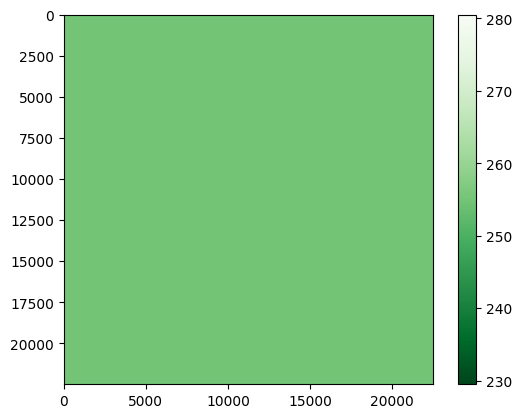

In [89]:
with rasterio.open(raster_path) as src:
    array = src.read(1) # Read first band
    profile = src.profile
    
    if None is None:
        nodata_val = profile['nodata']

    plt.imshow(array, cmap='Greens_r')
    plt.colorbar()

In [82]:
# Step 1: Read and mask the raster
raster_array, raster_profile = read_and_mask_raster(raster_path, min_val, max_val, -1)

/var/folders/gr/150_8wbn02s9rdqqvb4pbblh0000gn/T/ipykernel_8822/4041353839.py:23: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of -1 to uint8 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  array[(array < min_val) | (array > max_val)] = nodata_val


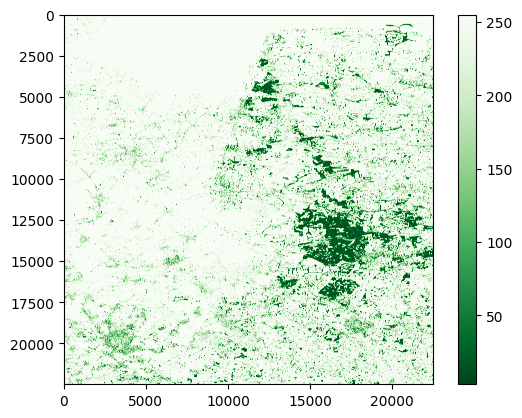

In [83]:
plt.imshow(raster_array, cmap='Greens_r')
plt.colorbar()

In [84]:
clip_raster_with_vector(raster_array, raster_profile, vector_path, output_path)

AttributeError: 'numpy.ndarray' object has no attribute 'nodata'

In [90]:
def clip_and_mask_raster(raster_path, vector_path, output_path, min_val, max_val):
    """
    Clips a raster with a vector mask, masks out values outside the specified range, 
    and saves the output to a new file.

    Parameters:
        raster_path (str): Path to the raster file.
        vector_path (str): Path to the vector mask file.
        output_path (str): Where to save the clipped and masked raster.
        min_val (float): Minimum value to keep.
        max_val (float): Maximum value to keep.
    """
    # Load the vector mask
    vector_mask = gpd.read_file(vector_path)
    
    with rasterio.open(raster_path) as src:
        # Ensure the vector mask is in the same CRS as the raster
        vector_mask = vector_mask.to_crs(src.crs)
        
        # Clip the raster using the vector mask
        out_image, out_transform = mask(src, getFeatures(vector_mask), crop=True)
        
        # Retrieve nodata value from the raster metadata
        nodata = src.nodata
        
        # Mask out values outside the specified range
        out_image = np.where(
            (out_image < min_val) | (out_image > max_val),
            nodata,  # Use existing nodata value where condition is True
            out_image  # Keep original values where condition is False
        )
        
        # Prepare metadata for the output file
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
    
    # Write the clipped and masked raster to a new file
    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(out_image)


In [93]:

# Example usage
clip_and_mask_raster(
    raster_path,
    vector_path,
    output_path,
    min_val,
    max_val
)



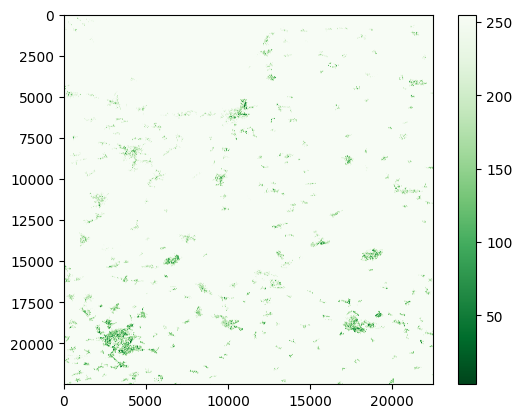

In [5]:
with rasterio.open(output_path) as src:
    array = src.read(1) # Read first band
    profile = src.profile
    
    if None is None:
        nodata_val = profile['nodata']

    plt.imshow(array, cmap='Greens_r')
    plt.colorbar()

In [6]:
src_grain = rasterio.open(output_path)
shapes = rasterio.features.shapes(src_grain, connectivity=8)
shapes

<generator object shapes at 0x31346f740>

In [7]:
pol = list[shapes]
pol

list[<generator object shapes at 0x31346f740>]

In [8]:
geom = [shapely.geometry.shape(i[0]) for i in pol]
geom = gpd.GeoSeries(geom, crs=src_grain.crs)
geom

NameError: name 'shapely' is not defined

In [14]:
from geocube.vector import vectorize

In [10]:
data = rxr.open_rasterio(output_path, mask_and_scale=True).squeeze()
# data.name = "class"
x = vectorize(data)

/Users/ancazugo/Documents/PhD_Thesis/Tree_detection/.venv/lib/python3.12/site-packages/geocube/vector.py:62: UserWarning: The array has no name. Column name defaults to _data
  warnings.warn("The array has no name. Column name defaults to _data")


In [12]:
x.to_file(MASK_FOLDER / "vectorised_example.geojson")

In [13]:
MASK_FOLDER

PosixPath('/Users/ancazugo/Library/CloudStorage/GoogleDrive-acz25@cam.ac.uk/My Drive/PhD Thesis/data/geopackages')

In [15]:
len(x)

4081424

In [16]:
y = x.dissolve()

In [17]:
y.to_file(MASK_FOLDER / "vectorised_example_dissolved.geojson")

In [18]:
building = gpd.read_file("/Users/ancazugo/Downloads/cam-gb-mm-bha-01/mm-bha/2017_10/gdb/tl/tl4560.gdb/a00000009.gdbtable")

In [20]:
from shapely.ops import nearest_points

In [36]:


# Initialize an R-tree spatial index for layer_many
sindex = building.sindex

# Define a function to find the closest point using spatial indexing to narrow down candidates
def find_closest_point_with_index(single_geom, many_gdf):

    # Assuming layer_single has only one feature, extract that single geometry
    single_feature_geom = single_geom.geometry.iloc[0]
    # Find approximate nearest neighbors in the R-tree index
    # This returns the indices of n nearest neighbors in the 'many' layer
    nearest_idx = list(sindex.nearest(single_geom.bounds, 1))
    
    # Retrieve the actual nearest geometry using these indices
    nearest_geom = many_gdf.iloc[nearest_idx].geometry
    
    # Calculate and return the actual nearest point
    return nearest_points(single_geom, nearest_geom.iloc[0])[1]

In [34]:
sindex

In [37]:
# Using tqdm for a progress bar (useful for large datasets)
# If you don't need a progress bar, you can remove tqdm()
building['closest_point'] = [find_closest_point_with_index(y, building) for _ in tqdm(range(len(building)))]

# Apply the function to each row in layer_many
# building['closest_point'] = building.apply(find_closest_point, target_geom=single_feature_geom, axis=1)


  0%|          | 0/19618 [00:00<?, ?it/s]


TypeError: Array should be one dimensional

In [26]:
from tqdm import tqdm

In [38]:
import geopandas as gpd
from shapely.ops import nearest_points
from concurrent.futures import ProcessPoolExecutor
import os

# Extract the single feature geometry
single_feature_geom = y.geometry.iloc[0]


In [39]:

def find_closest_point(feature, single_geom):
    """
    Find the closest point on single_geom to the given feature.
    This function is designed to be called in parallel.
    """
    return nearest_points(feature, single_geom)[1]

def process_feature(index_geom):
    """
    Wrapper function to process each feature. This extracts the feature geometry
    and passes it to the function calculating the closest point.
    """
    index, geom = index_geom
    return index, find_closest_point(geom, single_feature_geom)


In [65]:

# Tuple of (index, geometry) for each feature in layer_many
# features = list(building.geometry.iteritems())
features = [(i, building.iloc[i].geometry) for i in range(len(building[:100]))]
# Number of parallel processes to use
num_processes = os.cpu_count()

# Execute the find_closest_point function in parallel
with ProcessPoolExecutor(max_workers=num_processes) as executor:
    # Map the process_feature function across all features, in parallel
    results = list(executor.map(process_feature, features))

# Sort results by the original index to maintain order
results.sort(key=lambda x: x[0])

# Extract the closest points from the results
closest_points = [result[1] for result in results]

# Assign the closest points to the 'closest_point' column in the original GeoDataFrame
building['closest_point'] = closest_points

building


Process SpawnProcess-1:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/concurrent/futures/process.py", line 251, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.12/3.12.2_1/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'process_feature' on <module '__main__' (<class '

BrokenProcessPool: A child process terminated abruptly, the process pool is not usable anymore